In [0]:
import pandas as pd
file_path ="/Volumes/workspace/default/netflix/netflix_FutureEnginnering.csv"
df = pd.read_csv(file_path)
display(df.head(5))

show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Content_Length_Category,Title_Length_Category,Original_vs_Licensed,Audience_Age_Group
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",Medium,Long Title,Original,Teens
s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",Regular Series,Medium Title,Licensed,Adults
s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",Mini-Series,Short Title,Licensed,Adults
s4,Tv Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",Mini-Series,Long Title,Licensed,Adults
s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",Regular Series,Medium Title,Licensed,Adults


In [0]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt


In [0]:
df_exploded = df.copy()
df_exploded['country'] = df_exploded['country'].fillna('Unknown')
df_exploded['listed_in'] = df_exploded['listed_in'].fillna('Unknown')

df_exploded = df_exploded.assign(
    country=df_exploded['country'].str.split(','),
    genre=df_exploded['listed_in'].str.split(',')
).explode('country').explode('genre')

df_exploded['country'] = df_exploded['country'].str.strip()
df_exploded['genre'] = df_exploded['genre'].str.strip()


In [0]:
country_genre_counts = (
    df_exploded.groupby(['country', 'genre'])
    .size()
    .reset_index(name='content_count')
)

display(country_genre_counts.sort_values('content_count', ascending=False).head(10))


country,genre,content_count
India,International Movies,864
United States,Dramas,835
United States,Comedies,680
India,Dramas,662
United States,Documentaries,512
United States,Action & Adventure,404
United States,Independent Movies,390
United States,Children & Family Movies,390
India,Comedies,323
United States,Thrillers,292


In [0]:
top_countries = df_exploded['country'].value_counts().head(10).index.tolist()
top_genres = df_exploded['genre'].value_counts().head(10).index.tolist()

df_exploded['is_top_country'] = df_exploded['country'].isin(top_countries).astype(int)
df_exploded['is_top_genre'] = df_exploded['genre'].isin(top_genres).astype(int)

# Extract numeric duration (Content Length)
df_exploded['duration'] = df_exploded['duration'].astype(str).str.extract(r'(\d+)').fillna(0).astype(int)
df_exploded['content_age_years'] = 2025 - df_exploded['release_year']
df_exploded['rating'] = df_exploded['rating'].fillna('Unknown')


In [0]:
from sklearn.linear_model import LogisticRegression

feature_cols = ['duration', 'content_age_years', 'is_top_genre']
X = df_exploded[feature_cols]
y = df_exploded['is_top_country']

clf = LogisticRegression(max_iter=200)
clf.fit(X, y)

driver_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': clf.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

display(driver_df)


Feature,Coefficient
is_top_genre,-0.5881147519511544
content_age_years,0.009215314006750266
duration,0.0011020583369819315


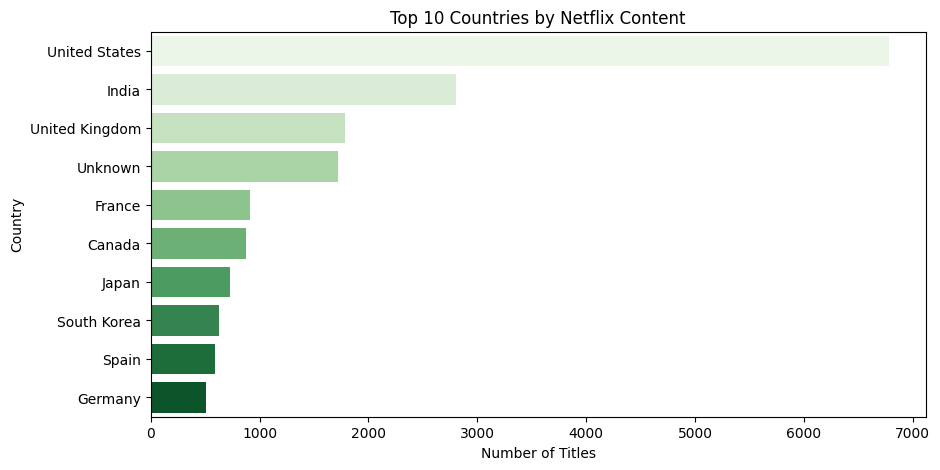

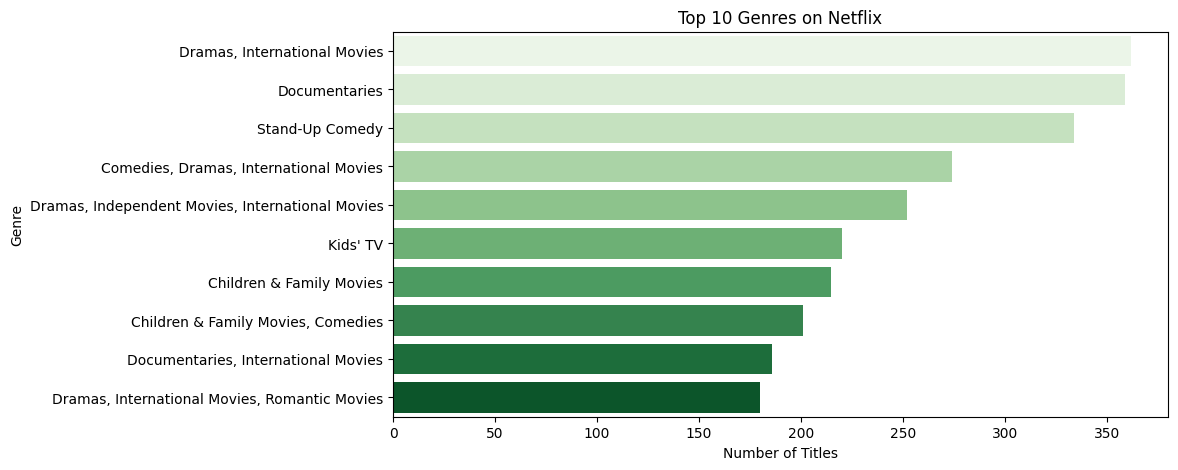

In [0]:
# Top countries
top_countries = df_exploded['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, 
            y=top_countries.index, 
            hue=top_countries.index, 
            palette='Greens',
            legend=False)
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

# Top genres
top_genres = df['listed_in'].value_counts().head(10)
plt.figure(figsize=(10,5))

sns.barplot(x=top_genres.values, 
            y=top_genres.index, 
            hue=top_genres.index, 
            palette='Greens',
            legend=False)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()


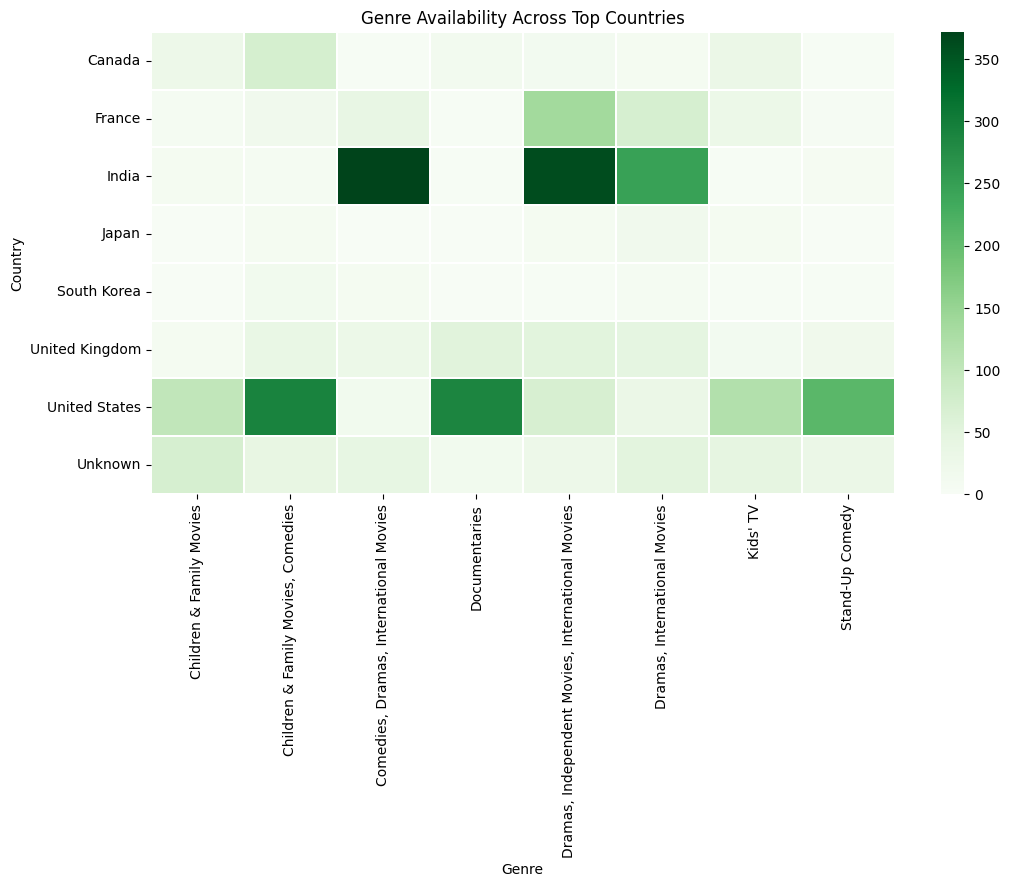

In [0]:
# Filter top countries and genres
top_country_list = df_exploded['country'].value_counts().head(8).index
top_genre_list = df['listed_in'].value_counts().head(8).index

filtered = df_exploded[
    df_exploded['country'].isin(top_country_list) & 
    df_exploded['listed_in'].isin(top_genre_list)
]

pivot = pd.crosstab(filtered['country'], filtered['listed_in'])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='Greens', linewidths=0.3)
plt.title('Genre Availability Across Top Countries')
plt.xlabel('Genre')
plt.ylabel('Country')
plt.show()


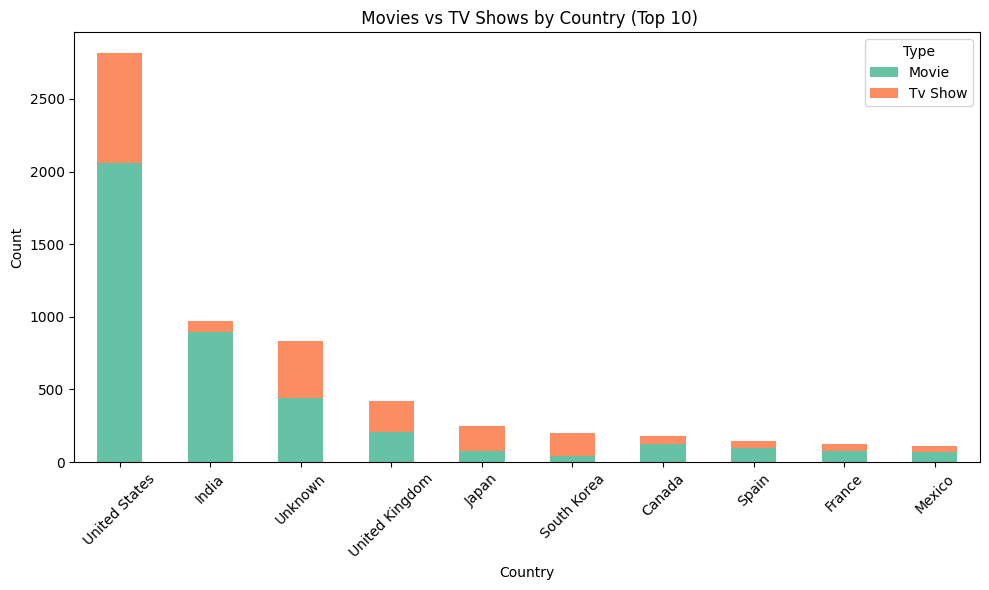

In [0]:

#  Counting Movies vs TV Shows by country
# ===============================================================
country_type = df.groupby(['country', 'type']).size().unstack(fill_value=0)
top_countries = country_type.sum(axis=1).sort_values(ascending=False).head(10)

# Filter top 10 countries only
country_type_top = country_type.loc[top_countries.index]

# Plot
country_type_top.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62'])
plt.title(' Movies vs TV Shows by Country (Top 10)')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


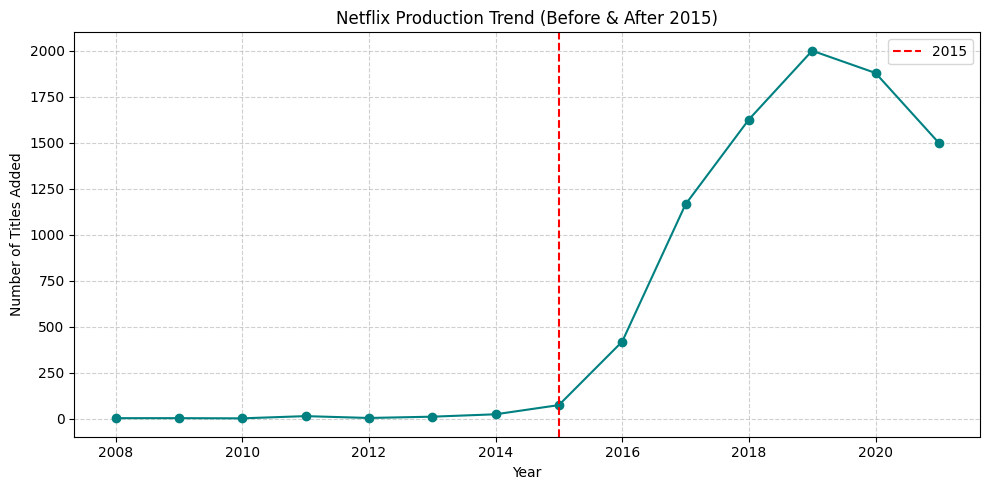

In [0]:
# Ensure 'date_added' is datetime
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)
df['year_added'] = df['date_added'].dt.year

trend = df.groupby('year_added').size()

plt.figure(figsize=(10, 5))
plt.plot(trend.index, trend.values, marker='o', color='teal')
plt.axvline(x=2015, color='red', linestyle='--', label='2015')
plt.title('Netflix Production Trend (Before & After 2015)')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()